# 15 Biweekly BiLSTM Attention Forecasting Pipeline

This notebook runs and reviews the biweekly BiLSTM-attention forecasting pipeline for the two M5 benchmark products:

- high-demand stable: `FOODS_3_228_CA_1_validation`
- intermittent: `FOODS_2_044_CA_3_validation`

The implementation lives in `src/experiments/run_biweekly_bilstm_attention.py`. This notebook is the project-facing workflow for training, visual inspection, and reporting.

## Pipeline Summary

- Input window: 28 days
- Forecast horizon: 14 days
- Validation protocol: 26 rolling biweekly windows
- Models: `BiLSTM-HighDemand` and `BiLSTM-Intermittent`
- Peak rule: `sales > rolling_mean_28d * 1.5`
- High-demand model: optimized primarily for smooth low-error forecasts
- Intermittent model: weighted Huber loss and early stopping on validation PDR

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main')

In [2]:
import pandas as pd
from IPython.display import Image, Markdown, display

from src.experiments.run_biweekly_bilstm_attention import (
    BiweeklyBiLSTMConfig,
    DEFAULT_OUT_DIR,
    SERIES_CONFIG,
    run_pipeline,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

SERIES_CONFIG

{'high_demand': {'series_id': 'FOODS_3_228_CA_1_validation',
  'model_name': 'BiLSTM-HighDemand',
  'loss_mode': 'huber',
  'early_stop_metric': 'val_loss',
  'smooth_predictions': True},
 'intermittent': {'series_id': 'FOODS_2_044_CA_3_validation',
  'model_name': 'BiLSTM-Intermittent',
  'loss_mode': 'weighted_huber',
  'early_stop_metric': 'val_pdr',
  'smooth_predictions': False}}

## Configuration

For a quick test, set `EPOCHS = 1`. For the real experiment, use `EPOCHS = 40` or higher. The notebook does not retrain by default if outputs already exist; set `RUN_TRAINING = True` when you want to regenerate the models and reports.

In [3]:
RUN_TRAINING = False
EPOCHS = 40
PATIENCE = 8
BATCH_SIZE = 32

config = BiweeklyBiLSTMConfig(
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=42,
)

DEFAULT_OUT_DIR, config

(WindowsPath('C:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/biweekly_bilstm_attention'),
 BiweeklyBiLSTMConfig(seed=42, lookback=28, horizon=14, train_days=1095, validation_cycles=26, batch_size=32, epochs=40, learning_rate=0.001, weight_decay=1e-05, patience=8, peak_multiplier=1.5, peak_weight=3.0, min_delta=0.0001))

## Run Training

This cell trains both models and writes predictions, metrics, figures, and `.pt` model files. Keep `RUN_TRAINING = False` if you only want to inspect already generated outputs.

In [4]:
if RUN_TRAINING:
    outputs = run_pipeline(DEFAULT_OUT_DIR, config)
else:
    outputs = {
        'out_dir': str(DEFAULT_OUT_DIR),
        'metrics': str(DEFAULT_OUT_DIR / 'biweekly_metrics_all.csv'),
        'predictions': str(DEFAULT_OUT_DIR / 'biweekly_predictions_all.csv'),
        'summary': str(DEFAULT_OUT_DIR / 'aggregate_metrics_summary.csv'),
        'pdr_heatmap': str(DEFAULT_OUT_DIR / 'figures' / 'pdr_heatmap_biweek_by_series.png'),
    }

outputs

{'out_dir': 'C:\\Users\\braya\\Documents\\Research\\aurex-demand-forecasting-main\\reports\\biweekly_bilstm_attention',
 'metrics': 'C:\\Users\\braya\\Documents\\Research\\aurex-demand-forecasting-main\\reports\\biweekly_bilstm_attention\\biweekly_metrics_all.csv',
 'predictions': 'C:\\Users\\braya\\Documents\\Research\\aurex-demand-forecasting-main\\reports\\biweekly_bilstm_attention\\biweekly_predictions_all.csv',
 'summary': 'C:\\Users\\braya\\Documents\\Research\\aurex-demand-forecasting-main\\reports\\biweekly_bilstm_attention\\aggregate_metrics_summary.csv',
 'pdr_heatmap': 'C:\\Users\\braya\\Documents\\Research\\aurex-demand-forecasting-main\\reports\\biweekly_bilstm_attention\\figures\\pdr_heatmap_biweek_by_series.png'}

## Load Outputs

In [5]:
out_dir = Path(outputs['out_dir'])
metrics_path = Path(outputs['metrics'])
predictions_path = Path(outputs['predictions'])
summary_path = Path(outputs['summary'])

missing = [path for path in [metrics_path, predictions_path, summary_path] if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Missing outputs. Set RUN_TRAINING = True and run the training cell first. Missing: ' + ', '.join(map(str, missing))
    )

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
summary = pd.read_csv(summary_path)

metrics.shape, predictions.shape, summary.shape

((52, 14), (728, 11), (2, 10))

## Final Aggregate Metrics

In [6]:
summary

,series_label,series_id,model_name,mean_mae,mean_rmse,mean_pdr,mean_variance_ratio,pct_windows_pdr_gt_0_5,missed_peak_windows,total_windows
0,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,3.991087,4.882169,0.216026,1.138607,0.153846,17,26
1,intermittent,FOODS_2_044_CA_3_validation,BiLSTM-Intermittent,1.243980,1.442966,0.803526,inf,0.807692,0,26


## Biweekly Metrics Table

Each row is one 14-day forecast window. `missed_all_peaks=True` means the window had actual peaks, but the model detected none.

In [7]:
display(metrics.head(10))

metrics.groupby('series_label')[['mae', 'rmse', 'pdr', 'variance_ratio']].mean().reset_index()

,series_label,series_id,model_name,biweek,window_start,window_end,mae,rmse,pdr,actual_peak_days,detected_peak_days,predicted_peak_days,variance_ratio,missed_all_peaks
0,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,1,2015-04-27,2015-05-10,5.226639,6.551671,0.0,5,0,1,0.447984,True
1,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,2,2015-05-11,2015-05-24,3.699763,4.522633,0.0,2,0,1,0.726784,True
2,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,3,2015-05-25,2015-06-07,4.605732,5.783250,0.0,3,0,1,0.650336,True
3,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,4,2015-06-08,2015-06-21,3.166173,5.371715,0.0,1,0,0,0.728823,True
4,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,5,2015-06-22,2015-07-05,3.681675,4.693877,0.0,1,0,0,1.014085,True
5,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,6,2015-07-06,2015-07-19,2.853828,3.457821,1.0,0,0,1,1.076827,False
6,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,7,2015-07-20,2015-08-02,4.181429,5.040972,0.0,1,0,1,0.913317,True
7,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,8,2015-08-03,2015-08-16,5.386775,6.875049,0.0,5,0,1,0.670678,True
8,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,9,2015-08-17,2015-08-30,4.274585,5.027717,0.0,1,0,1,0.679173,True
9,high_demand,FOODS_3_228_CA_1_validation,BiLSTM-HighDemand,10,2015-08-31,2015-09-13,4.337509,4.859354,1.0,0,0,1,0.981644,False


,series_label,mae,rmse,pdr,variance_ratio
0,high_demand,3.991087,4.882169,0.216026,1.138607
1,intermittent,1.243980,1.442966,0.803526,inf


## Missed-Peak Windows

In [8]:
missed = metrics.loc[metrics['missed_all_peaks'].astype(str).str.lower().isin(['true', '1'])].copy()
missed[['series_label', 'series_id', 'biweek', 'window_start', 'window_end', 'actual_peak_days', 'detected_peak_days', 'pdr', 'mae', 'rmse']]

,series_label,series_id,biweek,window_start,window_end,actual_peak_days,detected_peak_days,pdr,mae,rmse
0,high_demand,FOODS_3_228_CA_1_validation,1,2015-04-27,2015-05-10,5,0,0.0,5.226639,6.551671
1,high_demand,FOODS_3_228_CA_1_validation,2,2015-05-11,2015-05-24,2,0,0.0,3.699763,4.522633
2,high_demand,FOODS_3_228_CA_1_validation,3,2015-05-25,2015-06-07,3,0,0.0,4.605732,5.783250
3,high_demand,FOODS_3_228_CA_1_validation,4,2015-06-08,2015-06-21,1,0,0.0,3.166173,5.371715
4,high_demand,FOODS_3_228_CA_1_validation,5,2015-06-22,2015-07-05,1,0,0.0,3.681675,4.693877
6,high_demand,FOODS_3_228_CA_1_validation,7,2015-07-20,2015-08-02,1,0,0.0,4.181429,5.040972
7,high_demand,FOODS_3_228_CA_1_validation,8,2015-08-03,2015-08-16,5,0,0.0,5.386775,6.875049
8,high_demand,FOODS_3_228_CA_1_validation,9,2015-08-17,2015-08-30,1,0,0.0,4.274585,5.027717
10,high_demand,FOODS_3_228_CA_1_validation,11,2015-09-14,2015-09-27,1,0,0.0,3.729427,4.339004
11,high_demand,FOODS_3_228_CA_1_validation,12,2015-09-28,2015-10-11,2,0,0.0,3.844220,4.762858


## PDR Heatmap

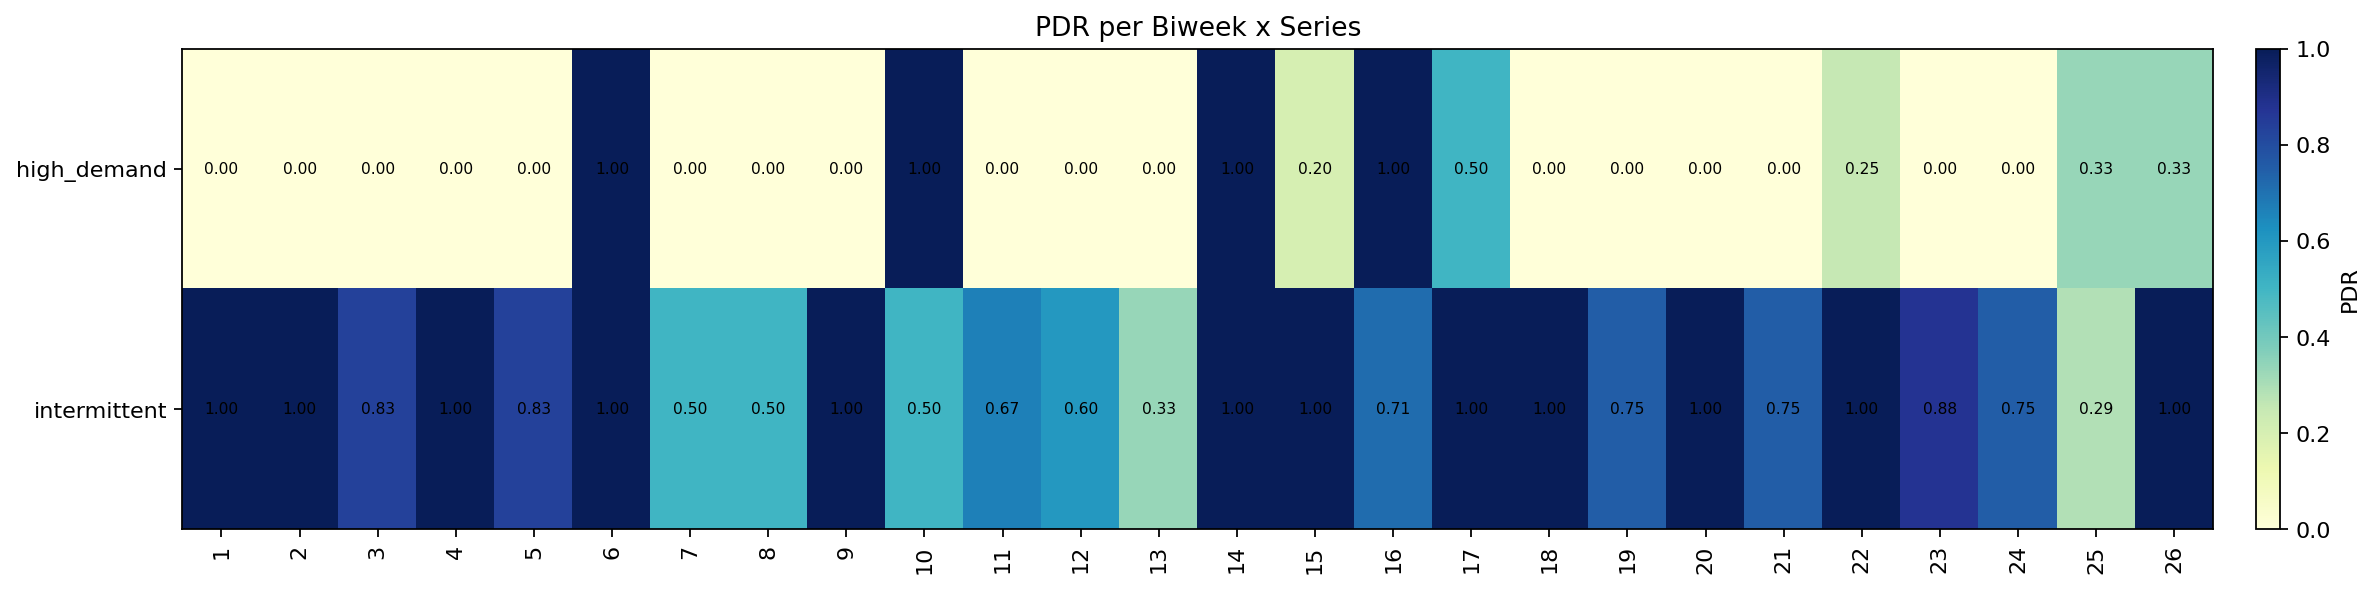

In [9]:
heatmap_path = out_dir / 'figures' / 'pdr_heatmap_biweek_by_series.png'
display(Image(filename=str(heatmap_path)))

## Training Curves

### high_demand

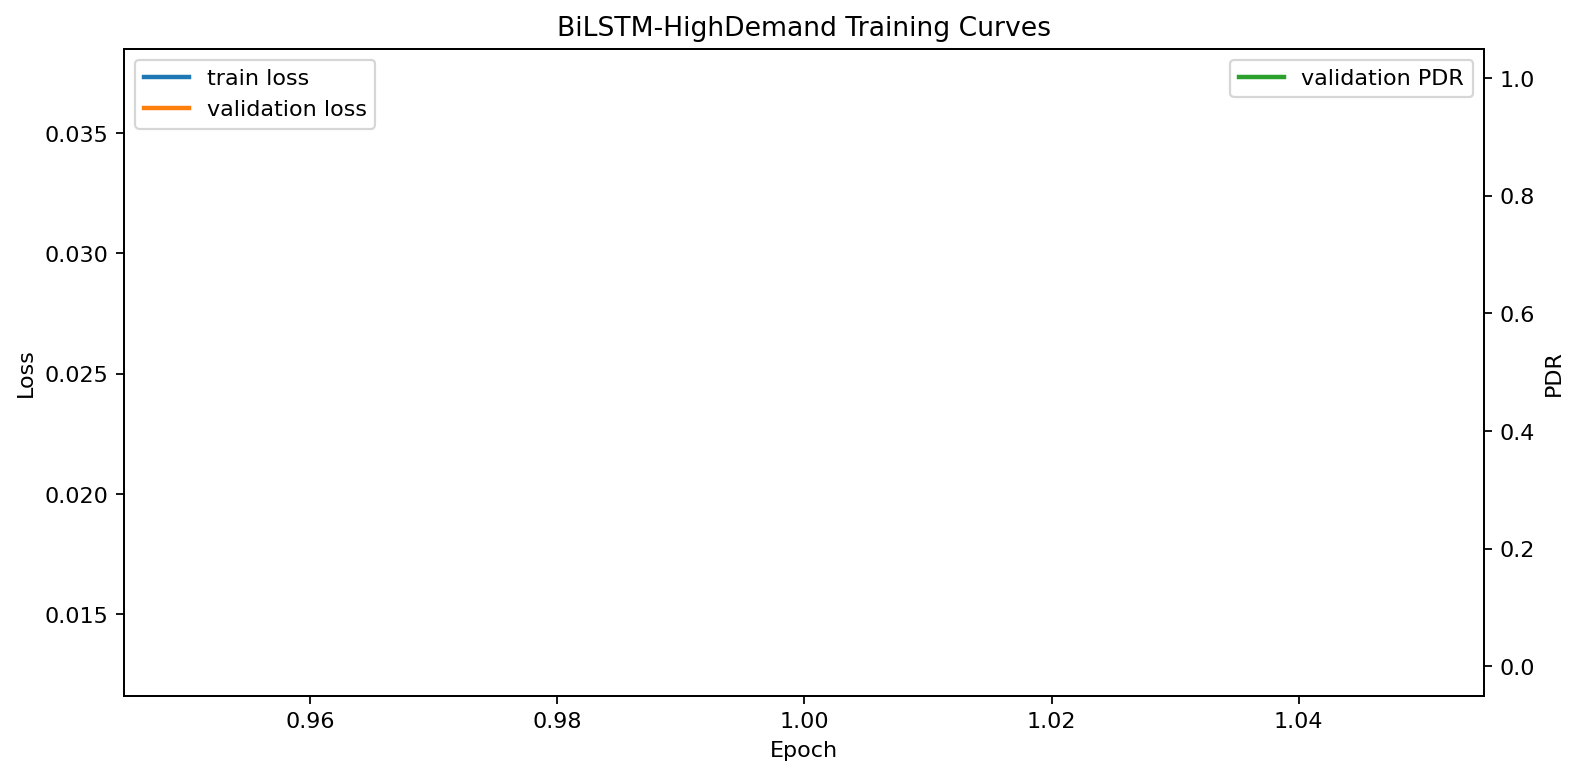

### intermittent

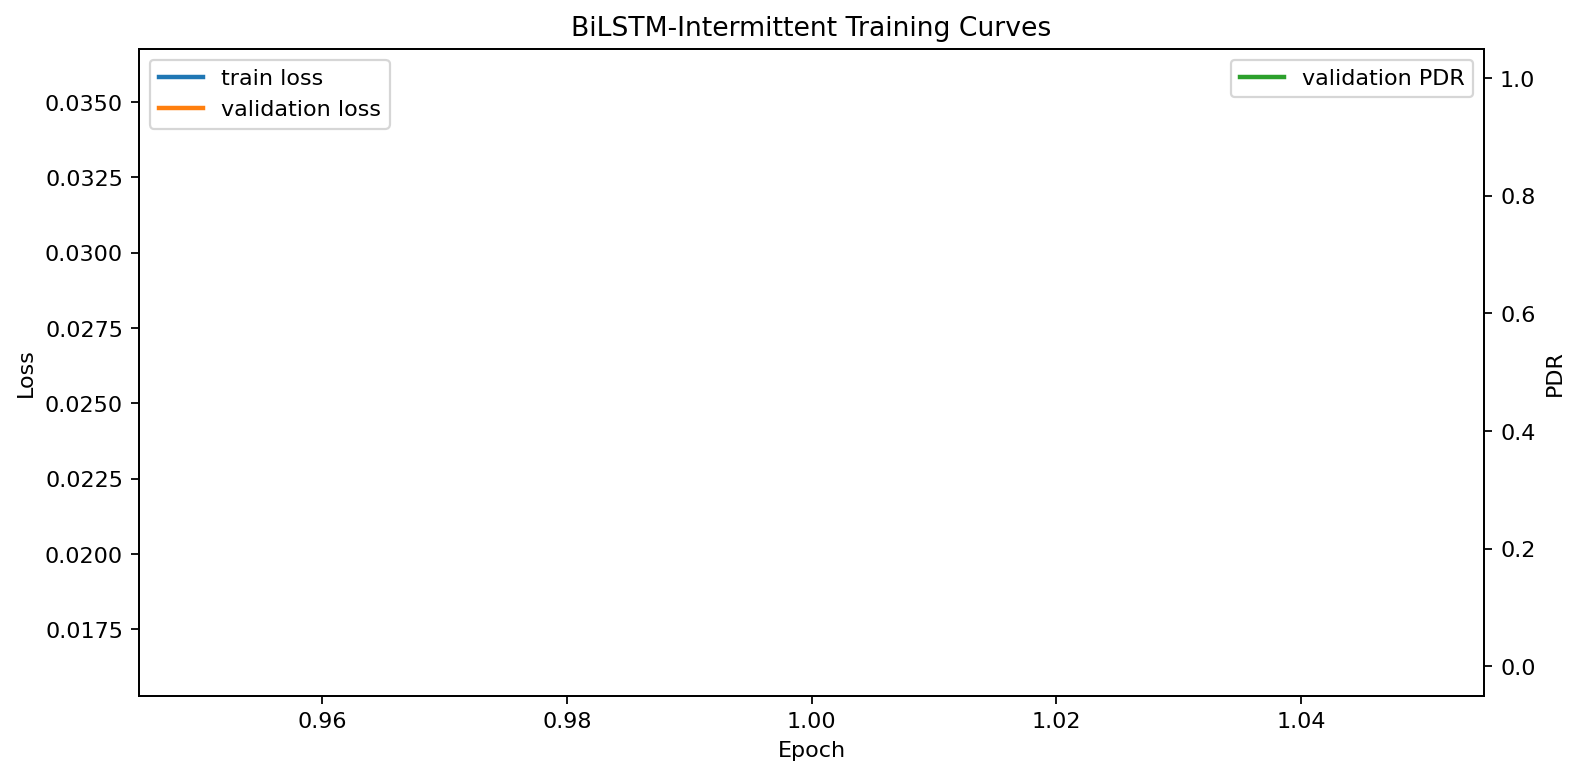

In [10]:
for label in ['high_demand', 'intermittent']:
    path = out_dir / 'figures' / f'{label}_training_loss_curve.png'
    display(Markdown(f'### {label}'))
    display(Image(filename=str(path)))

## Real vs Predicted: 26 Biweekly Windows

### high_demand

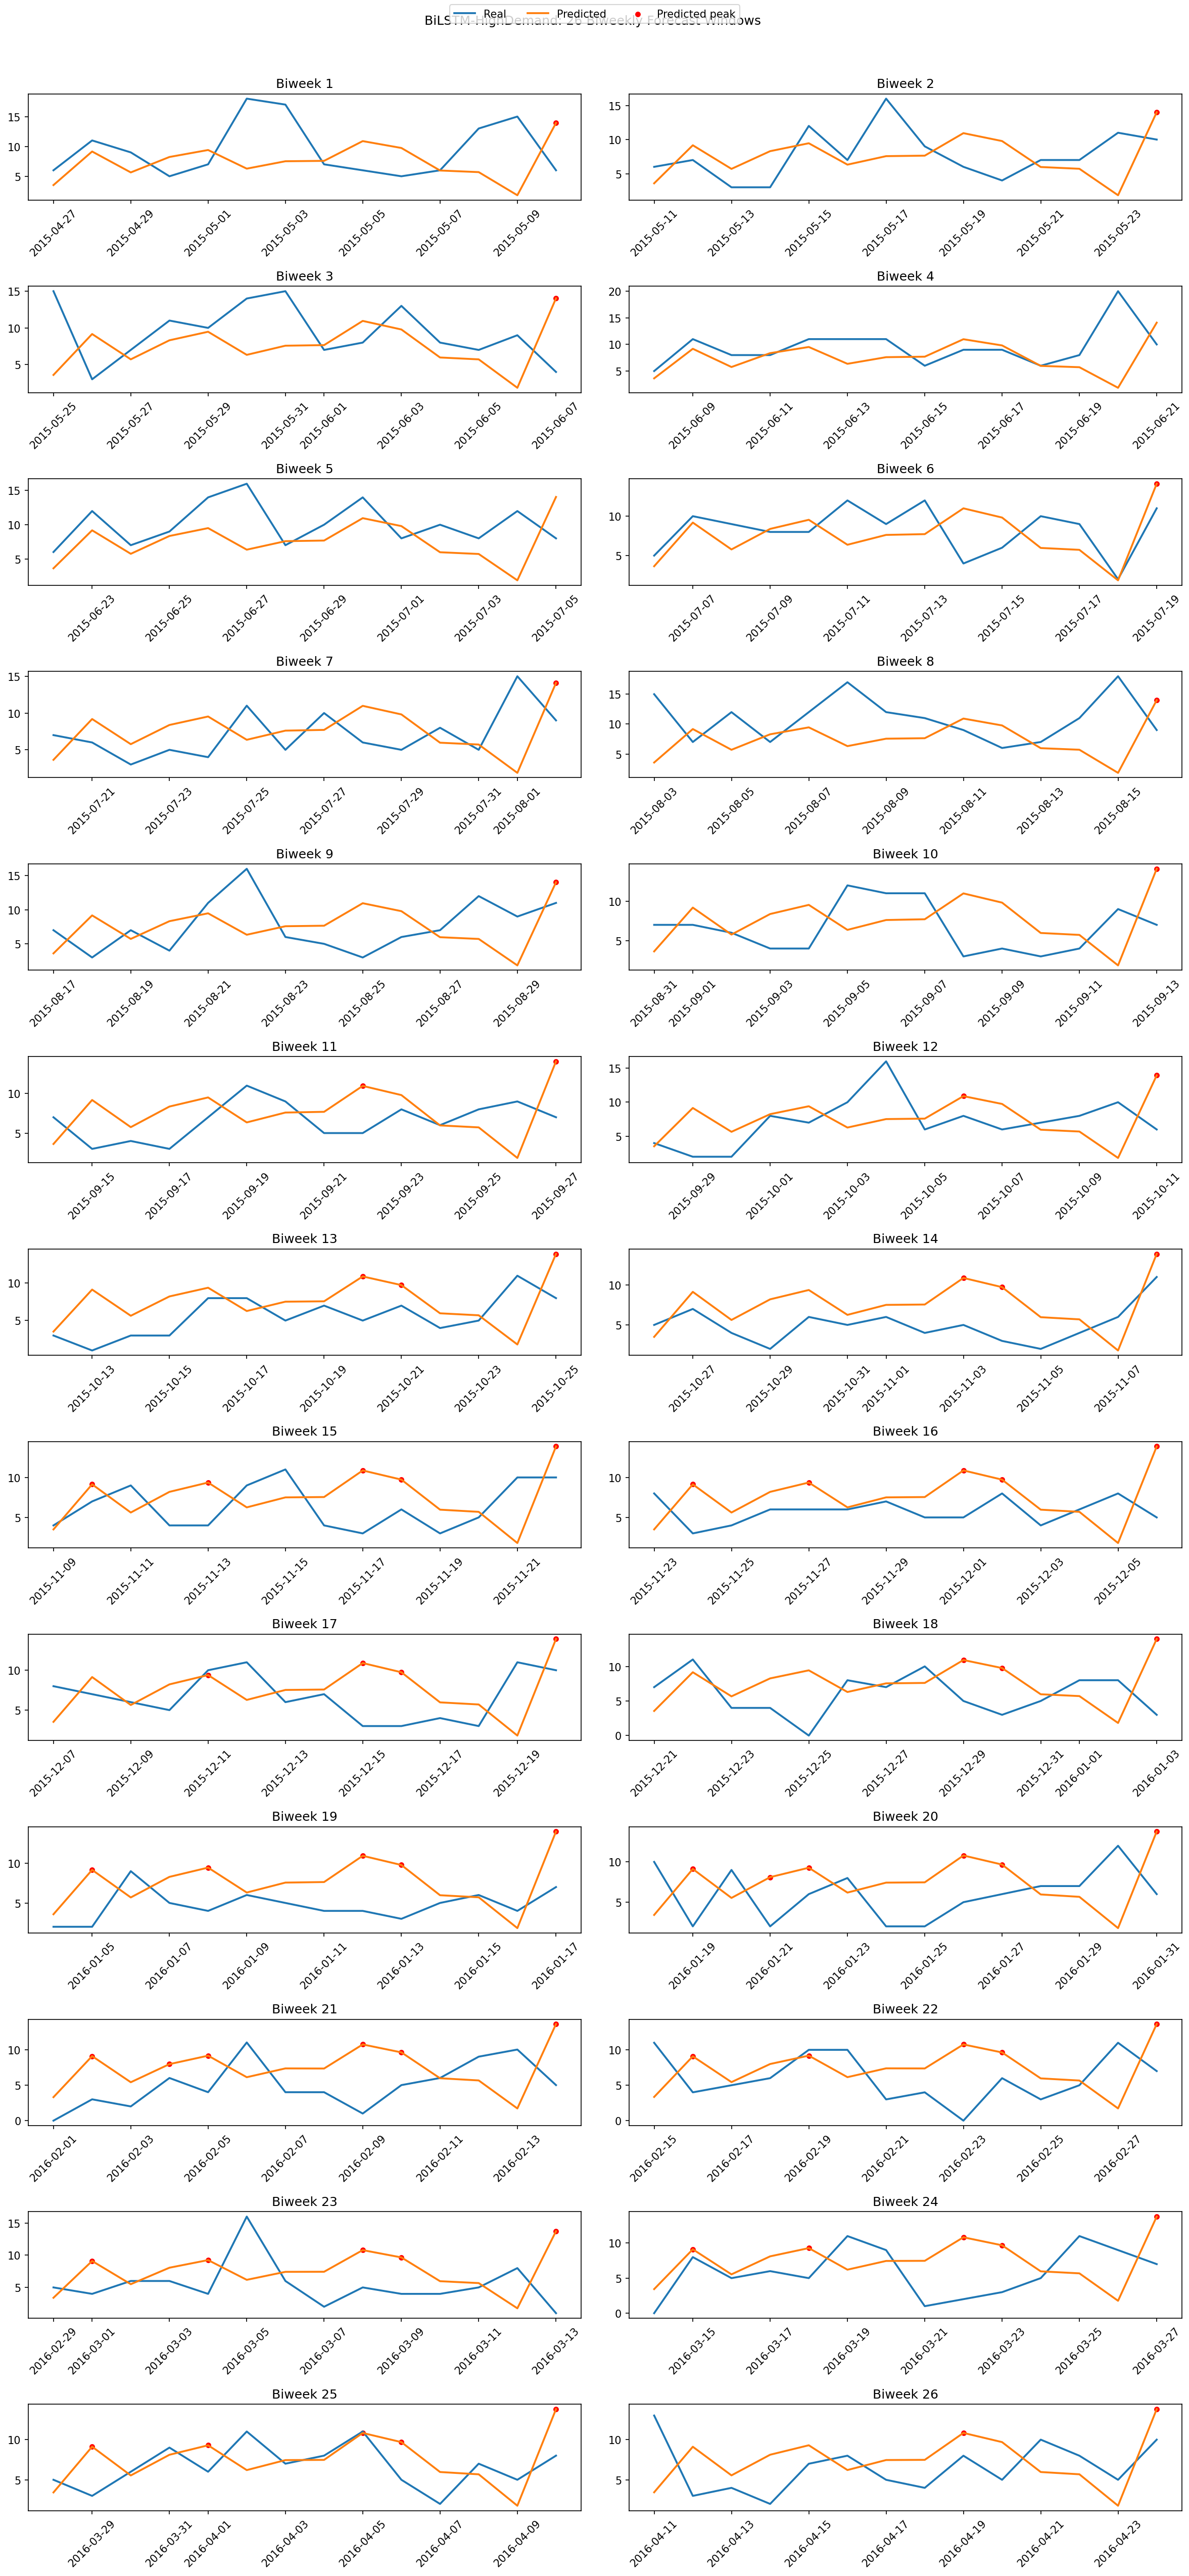

### intermittent

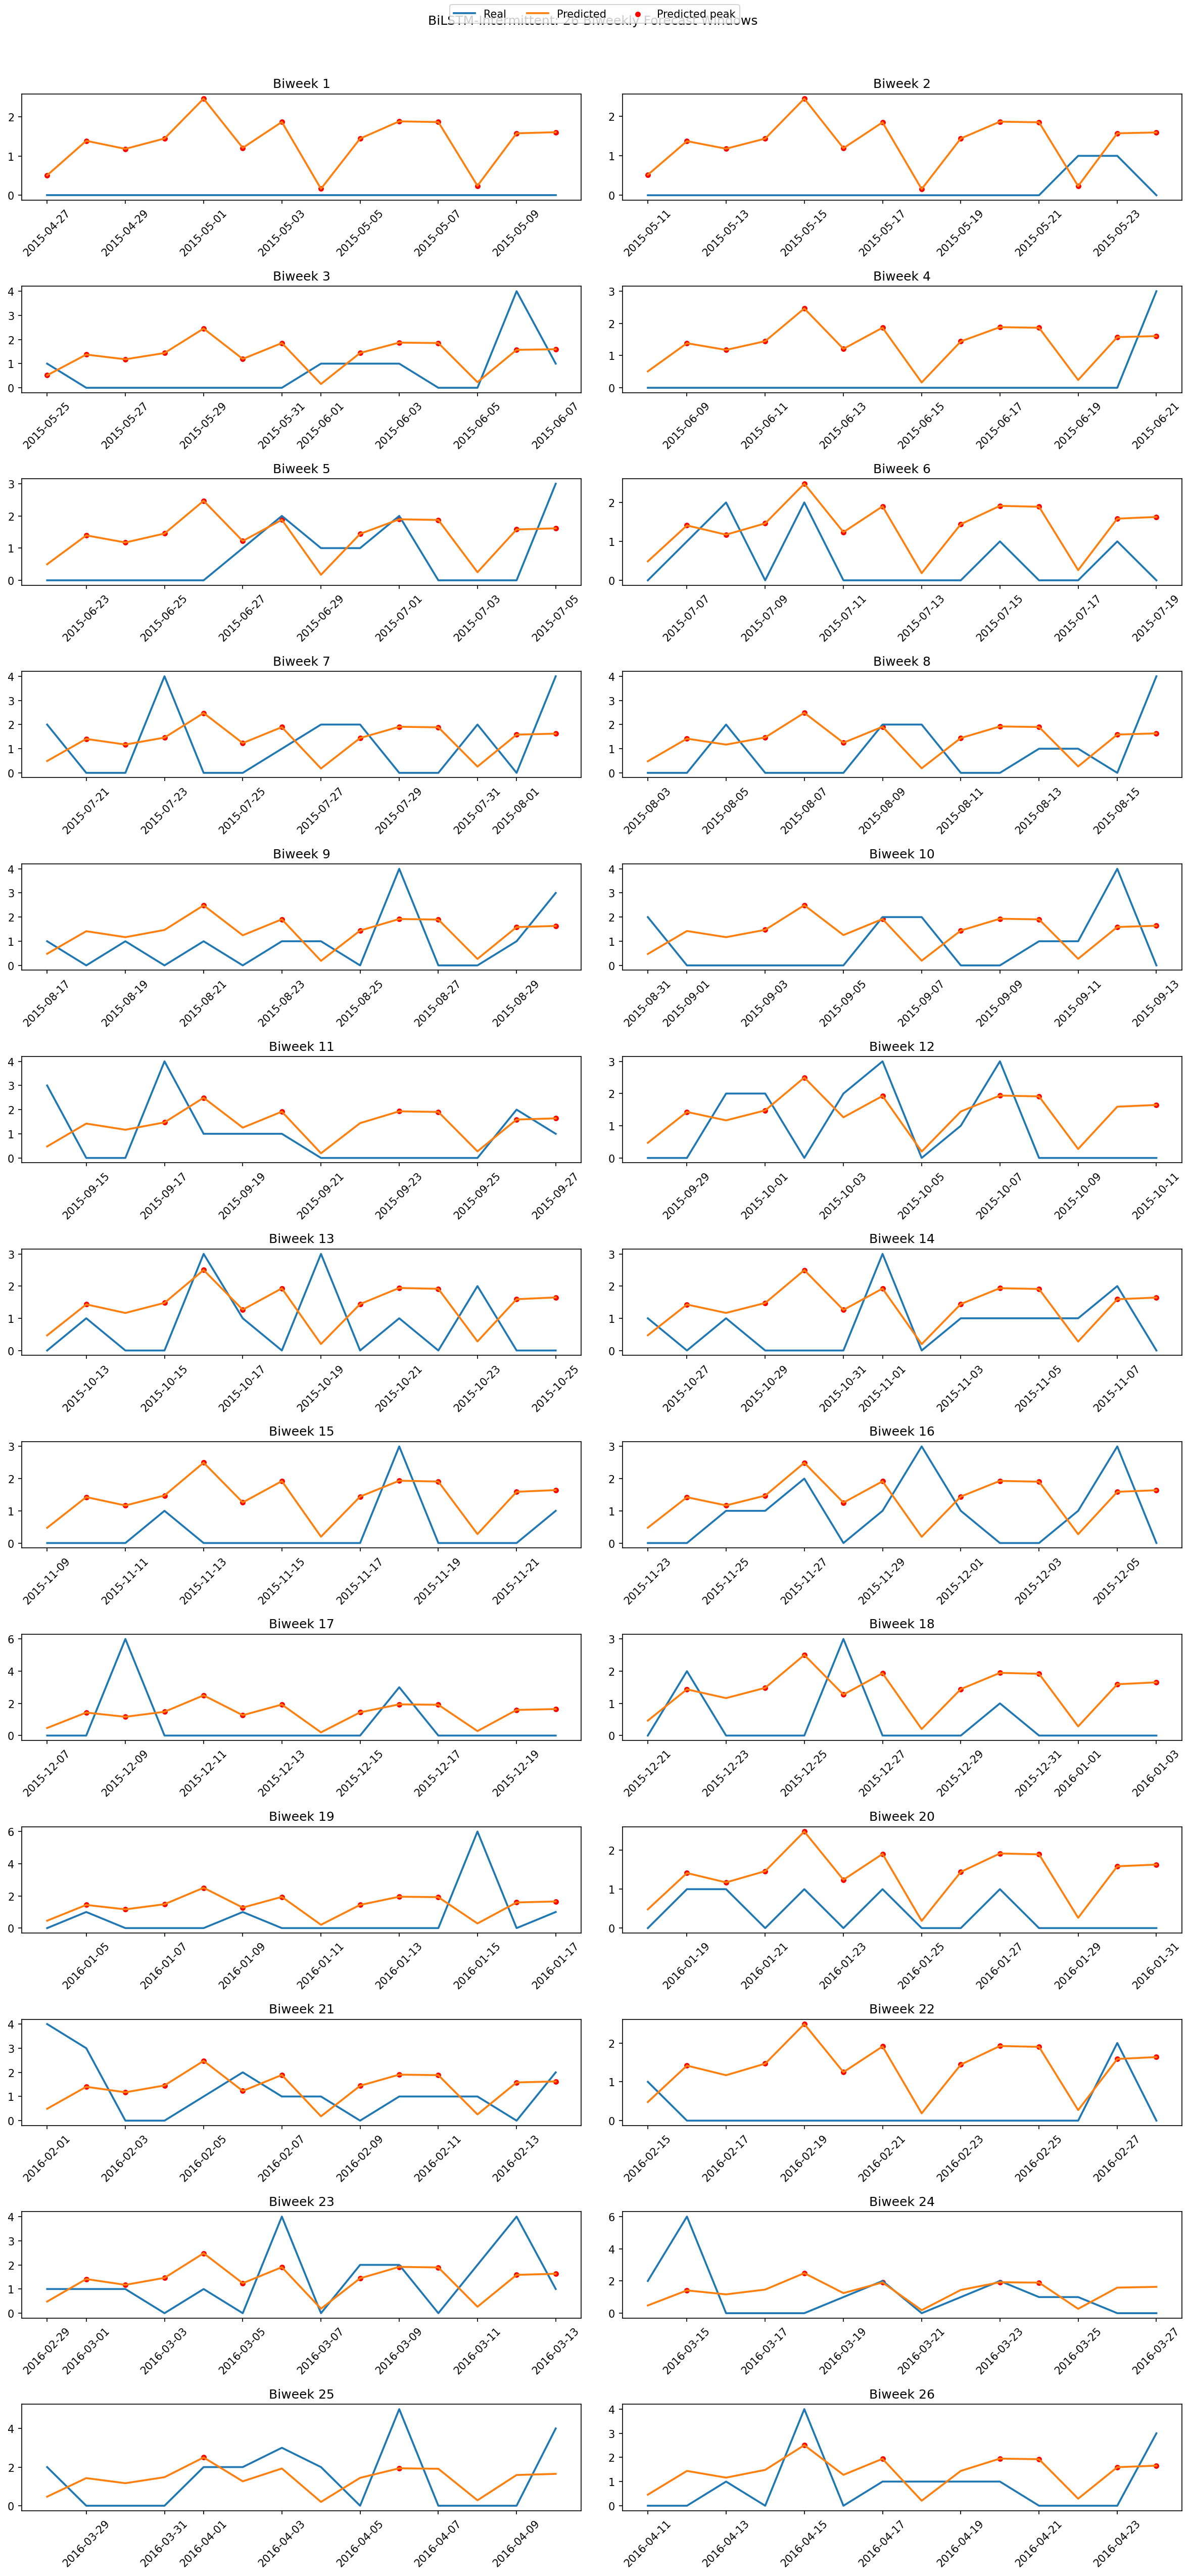

In [11]:
for label in ['high_demand', 'intermittent']:
    path = out_dir / 'figures' / f'{label}_biweekly_real_vs_predicted.png'
    display(Markdown(f'### {label}'))
    display(Image(filename=str(path)))

## Predicted Peak Flags

The prediction output includes one row per forecasted day, including actual sales, predicted sales, peak threshold, actual peak flag, and predicted peak flag.

In [12]:
cols = ['series_label', 'biweek', 'horizon_day', 'date', 'sales', 'y_pred', 'peak_threshold', 'is_actual_peak', 'is_predicted_peak']
predictions[cols].head(30)

,series_label,biweek,horizon_day,date,sales,y_pred,peak_threshold,is_actual_peak,is_predicted_peak
0,high_demand,1,1,2015-04-27,6.0,3.524445,10.875000,False,False
1,high_demand,1,2,2015-04-28,11.0,9.148077,10.875000,True,False
2,high_demand,1,3,2015-04-29,9.0,5.645958,11.196429,False,False
3,high_demand,1,4,2015-04-30,5.0,8.230606,11.303571,False,False
4,high_demand,1,5,2015-05-01,7.0,9.398845,11.196429,False,False
5,high_demand,1,6,2015-05-02,18.0,6.276989,10.875000,True,False
6,high_demand,1,7,2015-05-03,17.0,7.517214,11.196429,True,False
7,high_demand,1,8,2015-05-04,7.0,7.581503,11.196429,False,False
8,high_demand,1,9,2015-05-05,6.0,10.889326,11.089286,False,False
9,high_demand,1,10,2015-05-06,5.0,9.738901,11.250000,False,False


## Output Files

In [13]:
for path in [
    out_dir / 'biweekly_metrics_all.csv',
    out_dir / 'biweekly_predictions_all.csv',
    out_dir / 'aggregate_metrics_summary.csv',
    out_dir / 'training_history_all.csv',
    out_dir / 'figures' / 'pdr_heatmap_biweek_by_series.png',
    out_dir / 'models' / 'high_demand_bilstm_attention.pt',
    out_dir / 'models' / 'intermittent_bilstm_attention.pt',
]:
    print(path, 'exists=' + str(path.exists()))

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\biweekly_metrics_all.csv exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\biweekly_predictions_all.csv exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\aggregate_metrics_summary.csv exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\training_history_all.csv exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\figures\pdr_heatmap_biweek_by_series.png exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\models\high_demand_bilstm_attention.pt exists=True
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\biweekly_bilstm_attention\models\intermittent_bilstm_attention.pt exists=True
